# Four fleurons, and what the detectors recovered

Notebook 1 builds a detector for one fleuron and works through the method on it. This notebook
reports what four of them found across the whole corpus, and what a reviewer confirmed.

**The four are case studies, chosen one after another in response to what the previous one
measured, not a sample.** `Fleuron_2` came first for its distinctive outline. `Fleuron_74`
followed as a control, to test whether the result depended on that distinctiveness; it failed in
an unexpected way, by confusing its target with a different design. `Fleuron_73` was chosen
because it was the design `Fleuron_74` kept confusing, to test whether the confusion ran both
ways. `Fleuron_72` was added as a second large, well-attested class. Nothing here supports a
claim about the other 88 catalogue classes, and none is made.

---

**Reads** `4_detection_outputs/fleuron_*_v1/` (detections and frozen review labels),
`all_regions_outputs/candidate_boxes.csv` · **Writes** `4_detection_outputs/four_targets/` ·
**Chapter README** §4

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '4_detection', 'Run this notebook from its own folder, 4_detection/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
OUTPUTS = PROJECT_DIR/'4_detection_outputs'

RUN_TAG = ''
ALLOW_OVERWRITE = False
OUT = OUTPUTS/f'four_targets{RUN_TAG}'

IOU_MATCH = 0.40       # a detection is credited to a candidate region above this overlap
MIN_SIDE_APPLIED = 24  # the size filter applied between extraction and embedding

INK, FOIL, RULE, FLAG = '#444444', '#b0b7bd', '#b23a3a', '#1f4e79'
TARGETS = ['Fleuron_2', 'Fleuron_74', 'Fleuron_73', 'Fleuron_72']
ROLE = {'Fleuron_2': 'first target', 'Fleuron_74': 'control',
        'Fleuron_73': 'reciprocal test', 'Fleuron_72': 'second large class'}
print('targets, in the order they were run:', ', '.join(TARGETS))

targets, in the order they were run: Fleuron_2, Fleuron_74, Fleuron_73, Fleuron_72


## 1. What each detector proposed

Every detector was applied to all 613 scans. Each detection is compared with the candidate
regions the extraction stage produced for that scan and placed in one of six buckets, described
in notebook 1 §6. Only the buckets that represent something new were exported for review.

In [ ]:
reviewed, detections = {}, {}
for t in TARGETS:
    d = OUTPUTS/f'{t.lower()}_v1'
    detections[t] = pd.read_csv(d/'detections_flipsonly.csv')
    reviewed[t] = pd.read_csv(d/'review_new_detections'/'new_detections_reviewed.csv')

# `Fleuron_2` was the chapter's first target, and its export wrote only the two recovery folders.
# The confusion folder was added before the other three targets were run, so their confusions
# were judged and its 15 were not. They were reviewed separately, under the same one question
# and with the score and the catalogue's competing class hidden, and are folded in here so that
# every detection of every target carries a verdict and the per-target counts close against the
# detection totals. Without this, `Fleuron_2` reports zero confusions rather than fifteen.
conf_late = OUTPUTS/'fleuron_2_confusion_review'/'confusions_reviewed.csv'
if conf_late.exists():
    extra = pd.read_csv(conf_late).rename(columns={'catalogue_says': 'matched_class'})
    extra['bucket'] = 'other_catalogued'
    reviewed['Fleuron_2'] = pd.concat(
        [reviewed['Fleuron_2'], extra[['stem', 'conf', 'x1', 'y1', 'x2', 'y2',
                                       'bucket', 'matched_class', 'confirmed']]],
        ignore_index=True)
    print(f'folded in {len(extra)} separately reviewed Fleuron_2 confusions\n')
else:
    print('WARNING: the Fleuron_2 confusion review is missing, so its 15 confusions are '
          'uncounted.\nRun _tools/review_fleuron2_confusions.py.\n')

rows = []
for t in TARGETS:
    det, rev = detections[t], reviewed[t]
    rec = rev[rev.bucket != 'other_catalogued']
    conf = rev[rev.bucket == 'other_catalogued']
    rows.append(dict(target=t, role=ROLE[t], detections=len(det), scans=det.stem.nunique(),
                     reproduced_known=int((det.bucket == 'known_target').sum()),
                     reviewed=len(rev), recoveries_proposed=len(rec),
                     recoveries_confirmed=int(rec.confirmed.sum()),
                     confusions=len(conf), confusions_confirmed=int(conf.confirmed.sum())))
overview = pd.DataFrame(rows)
overview['recovery_precision'] = (overview.recoveries_confirmed /
                                  overview.recoveries_proposed).round(3)
print(overview.to_string(index=False))
print(f'\ntotals: {overview.reviewed.sum()} detections reviewed, '
      f'{overview.recoveries_confirmed.sum()} recoveries confirmed, '
      f'{overview.confusions.sum()} confusions of which '
      f'{overview.confusions_confirmed.sum()} were the target')

# Every detection is either reproduced from the catalogue, reviewed as a recovery, or reviewed
# as a confusion. Asserted rather than eyeballed, because the gap this closes went unnoticed
# until the arithmetic was checked against the detection totals.
unaccounted = overview.detections - overview.reproduced_known - overview.reviewed
assert (unaccounted == 0).all(), (
    f'detections with no verdict: {dict(zip(overview.target, unaccounted))}')
print(f'\nall {overview.detections.sum()} detections accounted for across the four targets')

**Recoveries and confusions are counted with separate denominators.** A detection landing on a
different catalogued fleuron is an error of identity, not a candidate recovery, and folding the
two together would misstate both. Not one of the 123 confusions was judged to be the target, so
the prior curation was correct in every disputed case.

`Fleuron_2`'s 15 confusions were reviewed after the other three targets and after this chapter
was first written, which is why they are folded in above rather than read from its review
directory. Until they were judged, the chapter counted 108 confusions and reported that figure
as though it covered every disputed case; it covered 108 of 123, with the rest neither confirmed
nor rejected. The assertion above now fails if any target's detections are left without a
verdict.

## 2. A correction: two extraction failures were being counted as one

The `no_otsu_candidate` bucket was originally read as "extraction never found this". That is not
what it measured. Detections were matched against the candidate set that reached the embedding
stage, and a size filter sits between the two: candidates whose shorter side falls below 24 px
are discarded before any crop is embedded. A detection landing on a discarded candidate recorded
no candidate at all, indistinguishably from one landing where extraction genuinely produced
nothing.

The cell below re-tests every confirmed recovery in that bucket against the **unfiltered**
extraction output, and separates the two.

In [3]:
full = pd.read_csv(PROJECT_DIR/'all_regions_outputs'/'candidate_boxes.csv')
full['min_side'] = full[['width', 'height']].min(axis=1)
by_scan = {s: g[['x_min', 'y_min', 'x_max', 'y_max', 'min_side']].to_numpy()
           for s, g in full.groupby('stem')}
print(f'extraction proposed {len(full):,} regions corpus-wide; '
      f'{int((full.min_side < MIN_SIDE_APPLIED).sum()):,} fall below the {MIN_SIDE_APPLIED} px '
      f'filter and were never embedded')


def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union > 0 else 0.0


refined = []
for t in TARGETS:
    for r in reviewed[t].itertuples():
        best, side = 0.0, np.nan
        if r.bucket == 'no_otsu_candidate':
            for c in by_scan.get(r.stem, []):
                v = iou((r.x1, r.y1, r.x2, r.y2), (c[0], c[1], c[2], c[3]))
                if v > best:
                    best, side = v, c[4]
        bucket = r.bucket
        if r.bucket == 'no_otsu_candidate':
            bucket = ('otsu_below_min_side' if best >= IOU_MATCH else 'no_candidate_any_size')
        refined.append(dict(target=t, bucket_original=r.bucket, bucket=bucket,
                            confirmed=r.confirmed, conf=r.conf,
                            candidate_min_side=side if best >= IOU_MATCH else np.nan))
R = pd.DataFrame(refined)

conf_only = R[R.confirmed & (R.bucket_original == 'no_otsu_candidate')]
split = conf_only.bucket.value_counts()
print(f"\nof the {len(conf_only)} confirmed recoveries in that bucket:")
print(f"  {split.get('no_candidate_any_size', 0)} had no extracted region at any size")
print(f"  {split.get('otsu_below_min_side', 0)} had one, discarded by the size filter")
print(f"\nby target:")
print(conf_only.groupby(['target', 'bucket']).size().unstack(fill_value=0).to_string())

extraction proposed 30,804 regions corpus-wide; 9,054 fall below the 24 px filter and were never embedded



of the 436 confirmed recoveries in that bucket:
  365 had no extracted region at any size
  71 had one, discarded by the size filter

by target:
bucket      no_candidate_any_size  otsu_below_min_side
target                                                
Fleuron_2                      17                    9
Fleuron_72                    272                   62
Fleuron_73                     63                    0
Fleuron_74                     13                    0


## 3. What the size filter costs, priced rather than asserted

The second group is not a connected-component failure and must not be reported as one. It has a
remedy the first does not: lower the threshold. That remedy can be priced exactly, because the
cost is a corpus-wide count.

The gain below is a floor: it counts only impressions of the four designs a detector was trained
for, and says nothing about the other 88.

In [4]:
small = conf_only[conf_only.bucket == 'otsu_below_min_side']
price = []
for thr in [24, 22, 20, 18, 16, 14, 12]:
    admitted = int(((full.min_side >= thr) & (full.min_side < MIN_SIDE_APPLIED)).sum())
    recovered = int((small.candidate_min_side >= thr).sum())
    price.append(dict(min_side=thr, extra_regions=admitted, known_impressions=recovered,
                      regions_per_impression=round(admitted/recovered, 1) if recovered else np.nan))
price = pd.DataFrame(price)
print(price.to_string(index=False))
print(f'\nthe discarded regions behind those {len(small)} recoveries have a shorter side of '
      f'{small.candidate_min_side.min():.0f}-{small.candidate_min_side.max():.0f} px '
      f'(median {small.candidate_min_side.median():.0f})')
print('\nFor comparison, Chapter 3 recovers one confirmed impression per 3.4 crops inspected.')

 min_side  extra_regions  known_impressions  regions_per_impression
       24              0                  0                     NaN
       22           1664                 25                    66.6
       20           3527                 60                    58.8
       18           5656                 69                    82.0
       16           7554                 71                   106.4
       14           8595                 71                   121.1
       12           8961                 71                   126.2

the discarded regions behind those 71 recoveries have a shorter side of 17-23 px (median 20)

For comparison, Chapter 3 recovers one confirmed impression per 3.4 crops inspected.


## 4. The reviewed result

Every proposal was reviewed by hand, by deleting the crops that were not the target. The
`confirmed` column of each review table is the record; counting surviving files would be wrong,
because curation moved files in and out of those folders for other reasons.

In [5]:
buckets = (R[R.bucket != 'other_catalogued']
           .groupby('bucket').confirmed.agg(proposed='size', confirmed='sum'))
buckets['precision'] = (buckets.confirmed/buckets.proposed).round(3)
order = ['no_candidate_any_size', 'otsu_below_min_side', 'otsu_box_fragment',
         'otsu_box_merged', 'otsu_box_ok_uncurated']
buckets = buckets.reindex([b for b in order if b in buckets.index])
print(buckets.to_string())
print(f'\ntotal: {buckets.proposed.sum()} proposed, {buckets.confirmed.sum()} confirmed '
      f'({buckets.confirmed.sum()/buckets.proposed.sum():.3f})')

attributable = buckets.loc[[b for b in buckets.index if b != 'otsu_box_ok_uncurated'],
                           'confirmed'].sum()
print(f'\n{attributable} of {buckets.confirmed.sum()} confirmed recoveries are attributable to '
      f'the extraction stage\n(no region, a region below the size filter, a fragment, or a '
      f'merge), and {buckets.loc["otsu_box_ok_uncurated", "confirmed"]} to an adequate region '
      f'that was never carried into the catalogue.')

                       proposed  confirmed  precision
bucket                                               
no_candidate_any_size       401        365      0.910
otsu_below_min_side          75         71      0.947
otsu_box_fragment            52         44      0.846
otsu_box_merged             185        164      0.886
otsu_box_ok_uncurated       122         58      0.475

total: 835 proposed, 702 confirmed (0.841)

644 of 702 confirmed recoveries are attributable to the extraction stage
(no region, a region below the size filter, a fragment, or a merge), and 58 to an adequate region that was never carried into the catalogue.


## 5. Confirmation against detection confidence, and why it proves less than it appears

Confirmation rises with the detector's confidence. It cannot be read as evidence that the score
is calibrated, because the exported crops were named with the confidence in the filename, so the
reviewer saw the score while judging. The gradient is reported as a guide to review burden at a
given operating point and nothing more. Notebook 3 establishes the score's behaviour without a
human in the loop.

In [6]:
Rr = R[R.bucket != 'other_catalogued'].copy()
Rr['band'] = pd.cut(Rr.conf, [0.25, 0.5, 0.75, 0.9, 1.0],
                    labels=['0.25-0.50', '0.50-0.75', '0.75-0.90', '0.90-1.00'],
                    include_lowest=True)
bands = Rr.groupby('band', observed=True).confirmed.agg(proposed='size', confirmed='sum')
bands['precision'] = (bands.confirmed/bands.proposed).round(3)
print(bands.to_string())

           proposed  confirmed  precision
band                                     
0.25-0.50       313        216      0.690
0.50-0.75       364        337      0.926
0.75-0.90       140        131      0.936
0.90-1.00        18         18      1.000


## 6. How repeatable is the review?

The 702 confirmations rest on one reviewer, working through folders sorted by bucket, with the
detector's confidence visible in every filename. A target-and-verdict-stratified sample of 100
detections was re-reviewed blind: scores stripped, order randomised across all four targets, no
record of the earlier verdict. Attribution buckets are observed rather than controlled.

The sample was drawn from the 943 detections reviewed in the first pass, so it does not include
`Fleuron_2`'s 15 confusions, which were judged later. The reweighted rate below therefore
describes those 943 rather than all 958, and the 15 carry no reliability estimate of their own.

In [7]:
rr = OUTPUTS/'reliability_check'/'rereview_scored.csv'
if rr.exists():
    k = pd.read_csv(rr)
    agree = int(k.agree.sum())
    a, b = k.confirmed.to_numpy().astype(bool), k.rereview.to_numpy().astype(bool)
    po = (a == b).mean()
    pe = a.mean()*b.mean() + (1-a.mean())*(1-b.mean())
    kappa = (po - pe)/(1 - pe)
    print(f'{agree} of {len(k)} judgements agree ({agree/len(k):.1%}), Cohen kappa {kappa:.3f}')
    strat = k.groupby(k.confirmed.map({True: 'originally confirmed',
                                       False: 'originally rejected'})).agree.agg(
        n='size', agreed='sum')
    strat['agreement'] = (strat.agreed/strat.n).round(3)
    print('\n' + strat.to_string())
    bybucket = k.groupby('bucket').agree.agg(n='size', agreed='sum')
    bybucket['agreement'] = (bybucket.agreed/bybucket.n).round(3)
    print('\nby attribution bucket:')
    print(bybucket.sort_values('n', ascending=False).to_string())
    w = k.stratum_size/k.stratum_drawn
    print(f'\nreweighted to the {int(w.sum())} reviewed detections, the second pass implies a '
          f'confirmation rate of {(w*k.rereview).sum()/w.sum():.3f} against '
          f'{(w*k.confirmed).sum()/w.sum():.3f} for the first')
else:
    print('no re-review found; run _tools/build_reliability_sample.py and review the sample')

97 of 100 judgements agree (97.0%), Cohen kappa 0.940

                       n  agreed  agreement
confirmed                                  
originally confirmed  52      51      0.981
originally rejected   48      46      0.958

by attribution bucket:
                        n  agreed  agreement
bucket                                      
no_otsu_candidate      37      37      1.000
otsu_box_ok_uncurated  28      26      0.929
otsu_box_merged        17      17      1.000
otsu_box_fragment       9       8      0.889
other_catalogued        9       9      1.000

reweighted to the 943 reviewed detections, the second pass implies a confirmation rate of 0.738 against 0.744 for the first


This is **intra-rater** reliability: it measures whether the reviewer repeats their own
judgements, not whether those judgements are correct. Both passes carry the same view of what
counts as the design, and a second reviewer could disagree systematically without this detecting
it. Kappa is prevalence-dependent and applies to this deliberately verdict-balanced frame.
Chapter 2's disagreement benchmark has the same single-reviewer limitation.

## 7. Figure

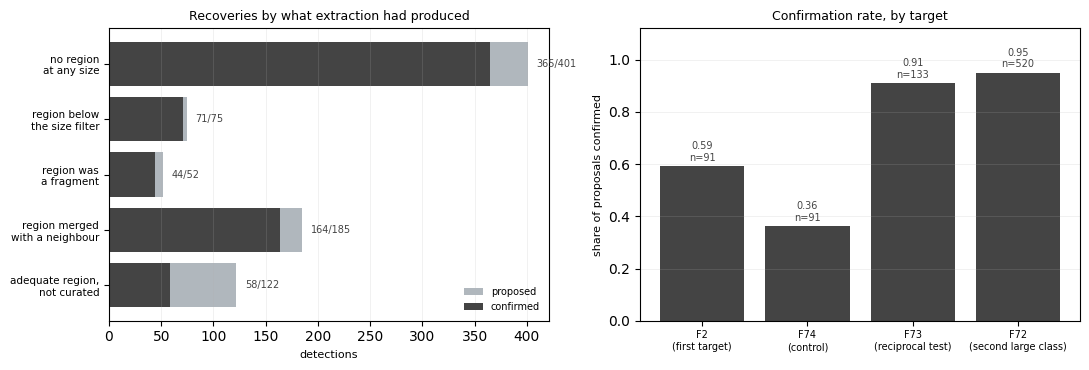

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
b = buckets.copy()
labels = {'no_candidate_any_size': 'no region\nat any size',
          'otsu_below_min_side': 'region below\nthe size filter',
          'otsu_box_fragment': 'region was\na fragment',
          'otsu_box_merged': 'region merged\nwith a neighbour',
          'otsu_box_ok_uncurated': 'adequate region,\nnot curated'}
y = np.arange(len(b))
ax.barh(y, b.proposed, color=FOIL, label='proposed')
ax.barh(y, b.confirmed, color=INK, label='confirmed')
for i, (p, c) in enumerate(zip(b.proposed, b.confirmed)):
    ax.text(p + 8, i, f'{c}/{p}', va='center', fontsize=7, color=INK)
ax.set_yticks(y)
ax.set_yticklabels([labels.get(i, i) for i in b.index], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel('detections', fontsize=8)
ax.set_title('Recoveries by what extraction had produced', fontsize=9)
ax.legend(fontsize=7, frameon=False, loc='lower right')
ax.grid(alpha=0.25, lw=0.5, axis='x')

ax = axes[1]
x = np.arange(len(overview))
ax.bar(x, overview.recovery_precision, color=INK)
for i, (v, n) in enumerate(zip(overview.recovery_precision, overview.recoveries_proposed)):
    ax.text(i, v + 0.02, f'{v:.2f}\nn={n}', ha='center', fontsize=7, color=INK)
ax.set_xticks(x)
ax.set_xticklabels([t.replace('Fleuron_', 'F') + f'\n({ROLE[t]})' for t in overview.target],
                   fontsize=7)
ax.set_ylim(0, 1.12)
ax.set_ylabel('share of proposals confirmed', fontsize=8)
ax.set_title('Confirmation rate, by target', fontsize=9)
ax.grid(alpha=0.25, lw=0.5, axis='y')

fig.tight_layout()
plt.show()

In [9]:
def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(f'{path} already contains results. Set RUN_TAG to write elsewhere, '
                           f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)
    return path


guarded_mkdir(OUT)
overview.to_csv(OUT/'per_target.csv', index=False)
R.to_csv(OUT/'recoveries_refined.csv', index=False)
buckets.to_csv(OUT/'by_bucket.csv')
price.to_csv(OUT/'min_side_price.csv', index=False)
bands.to_csv(OUT/'confidence_bands.csv')
fig.savefig(OUT/'four_targets.png', dpi=200, bbox_inches='tight')
print('written to', OUT.relative_to(PROJECT_DIR))

written to 4_detection_outputs/four_targets


## 8. What this establishes

**Impressions exist that the extraction stage could not produce a region for, and a detector
trained on the catalogue's own verified output finds them.** The count is the confirmed total in
§4, and the largest bucket has no overlapping unfiltered extraction box at IoU 0.40.

**The primary gain is completeness, with limited added reach.** The occurrence artifacts show
seven new work--class occurrences: one for `Fleuron_74`, two for `Fleuron_73`, and four for
`Fleuron_72`; `Fleuron_2` is unchanged. These are real additions for the selected targets, but
adaptive target selection prevents a catalogue-wide distribution claim.

**What is not established.** That this generalises to the other 88 classes; four designs were
tested and chosen sequentially. That the detector would discover designs absent from the
catalogue, since it can only learn what extraction surfaced at least sometimes. And that a
trained detector was *necessary*, which notebook 4 examines against a training-free baseline and
does not settle in the detector's favour.